# 02 — Model Selection & Cross-Asset Validation

**Part 1**: Grid search on SPY + threshold calibration + comparison table + feature importances  
**Part 2**: Cross-asset validation on SPY / DIA / QQQ

In [14]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_data
from src.features import build_features, COLUMN_ORDER
from src.models import RFCModel, XGBModel

In [15]:

df_raw = load_data('SPY')
X_raw = build_features(df_raw)

df_spy = X_raw.copy()

ma50  = df_raw['Close'].rolling(50).mean()
ma200 = df_raw['Close'].rolling(200).mean()
gc    = (ma50 > ma200).astype(int)
gc_clean = gc.reset_index(drop=True)

transition = np.zeros(len(df_spy), dtype=int)
label = gc_clean.iloc[0]
for i in range(1, len(gc_clean)):
    if gc_clean.iloc[i] != label:
        label = gc_clean.iloc[i]
        start = max(0, i - 30)
        transition[start:i] = 1

df_spy['Transition'] = transition

df_spy = df_spy.dropna().reset_index(drop=True)


X = df_spy[COLUMN_ORDER]
y = df_spy['Transition']

split = int(len(df_spy) * 0.75)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Train size: {len(X_train)}  |  positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test size:  {len(X_test)}   |  positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
X_train.head(500)

Train size: 4563  |  positives: 528 (11.6%)
Test size:  1521   |  positives: 150 (9.9%)


,Return,Volatility,Cumulated_Return_5d,RSI14,Volume_ROC,ATR,VIX_spike,Distance_GC,MA_velocity,MA50_slope,Distance_normalized,MA_cross_momentum
0,0.004467,0.016713,0.016961,46.488368,-43.405512,2.234624,1.204567,0.008671,-0.559688,-0.011881,0.897100,56.401916
1,-0.006671,0.016545,0.035946,42.632100,-6.475955,2.254456,1.181164,0.007573,-0.525657,-0.012497,0.773323,78.072559
2,-0.023506,0.017220,0.015363,37.116450,100.083207,2.342283,1.290078,0.006090,-0.496996,-0.013276,0.612880,111.845555
3,0.002751,0.016896,-0.018843,42.134791,-6.681045,2.284912,1.375873,0.004669,-0.527373,-0.013361,0.463347,136.775651
4,0.018976,0.017493,-0.004467,48.775373,116.568323,2.317493,1.265942,0.003368,-0.554404,-0.013777,0.329126,185.008422
...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.024239,0.027370,0.108194,51.334686,17.412655,2.021277,1.000913,-0.133283,0.337902,-0.009746,-6.334733,3.166486
496,0.019873,0.026972,0.094753,59.368646,6.010676,2.010571,0.950624,-0.132059,0.454877,-0.009155,-6.282232,3.994457
497,0.004192,0.026969,0.053231,61.863513,-35.087501,2.023605,0.937234,-0.131280,0.475285,-0.008949,-6.256581,4.157041
498,0.017262,0.027022,0.065462,58.405924,-31.755362,1.959830,0.926530,-0.130295,0.476080,-0.007728,-6.220185,3.756761


In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# most_frequent : always predict the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline (Most Frequent) ===")
print(classification_report(y_test, y_pred_dummy, 
      target_names=['No Transition', 'Transition'], zero_division=0))

#stratified: predict randomly according to class distriution
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
y_pred_strat = dummy_strat.predict(X_test)

print("=== Baseline (Stratified Random) ===")
print(classification_report(y_test, y_pred_strat,
      target_names=['No Transition', 'Transition'], zero_division=0))

=== Baseline (Most Frequent) ===
               precision    recall  f1-score   support

No Transition       0.90      1.00      0.95      1371
   Transition       0.00      0.00      0.00       150

     accuracy                           0.90      1521
    macro avg       0.45      0.50      0.47      1521
 weighted avg       0.81      0.90      0.85      1521

=== Baseline (Stratified Random) ===
               precision    recall  f1-score   support

No Transition       0.91      0.88      0.90      1371
   Transition       0.14      0.17      0.16       150

     accuracy                           0.81      1521
    macro avg       0.52      0.53      0.53      1521
 weighted avg       0.83      0.81      0.82      1521



In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

# ── Scorer ──────────────────────────────────────────────────
f1_transition = make_scorer(f1_score, zero_division=0)

# ── Distributions ───────────────────────────────────────────
param_dist = {
    'n_estimators':     randint(200, 600),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.01, 0.09),
    'subsample':        uniform(0.5, 0.4),
    'colsample_bytree': uniform(0.5, 0.4),
    'min_child_weight': randint(1, 10),      # utile sur classes rares
    'gamma':            uniform(0, 0.3),     # regularisation
}

# ── Split sur X_train uniquement ────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,   # early stopping
    verbosity=0,
    random_state=42
)

# ── Early stopping nécessite un eval_set ────────────────────
# RandomizedSearchCV ne le supporte pas nativement
# → on le passe via fit_params
last_train_idx, last_val_idx = list(tscv.split(X_train))[-1]
eval_set = [(X_train.iloc[last_val_idx], y_train.iloc[last_val_idx])]

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=100,
    scoring=f1_transition,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=False          # on refit manuellement avec early stopping
)

rs.fit(X_train, y_train,
       eval_set=eval_set,
       verbose=False)

print("Best params :", rs.best_params_)
print("Best CV F1  :", round(rs.best_score_, 3))

# ── Refit manuel avec early stopping sur le dernier fold ────
best = rs.best_params_
xgb_tuned = XGBClassifier(
    **best,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0,
    random_state=42
)
xgb_tuned.fit(
    X_train.iloc[last_train_idx], y_train.iloc[last_train_idx],
    eval_set=eval_set,
    verbose=False
)

print(f"Best n_estimators (early stopping) : {xgb_tuned.best_iteration}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params : {'colsample_bytree': np.float64(0.6975574860733739), 'gamma': np.float64(0.05364681276639864), 'learning_rate': np.float64(0.042982190612457394), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 327, 'subsample': np.float64(0.7273234413341887)}
Best CV F1  : 0.659
Best n_estimators (early stopping) : 138


In [17]:
xgb = XGBModel(n_estimators=138,
            max_depth=5,
            learning_rate=0.0430,
            subsample=0.7273,
            colsample_bytree=0.6976,
            gamma=0.0536,
            min_child_weight=1,
            eval_metric='logloss',
            verbosity=0
        )
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)
print("Threshold | Precision | Recall |  F1   | N_pred")
print("-" * 52)
for t in np.arange(0.3, 0.95, 0.05):
    pred = (y_proba_xgb >= t).astype(int)
    if pred.sum() > 0:
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f = f1_score(y_test, pred, zero_division=0)
        print(f"  {t:.2f}    |   {p:.3f}   |  {r:.3f} | {f:.3f} | {pred.sum()}")

Threshold | Precision | Recall |  F1   | N_pred
----------------------------------------------------
  0.30    |   0.442   |  0.893 | 0.592 | 303
  0.35    |   0.453   |  0.873 | 0.597 | 289
  0.40    |   0.468   |  0.867 | 0.607 | 278
  0.45    |   0.473   |  0.827 | 0.602 | 262
  0.50    |   0.496   |  0.827 | 0.620 | 250
  0.55    |   0.515   |  0.827 | 0.634 | 241
  0.60    |   0.559   |  0.827 | 0.667 | 222
  0.65    |   0.574   |  0.827 | 0.678 | 216
  0.70    |   0.599   |  0.827 | 0.695 | 207
  0.75    |   0.658   |  0.807 | 0.725 | 184
  0.80    |   0.701   |  0.780 | 0.738 | 167
  0.85    |   0.750   |  0.740 | 0.745 | 148
  0.90    |   0.826   |  0.633 | 0.717 | 115


In [18]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform

f1_transition = make_scorer(f1_score, zero_division=0)

param_dist = {
    'n_estimators':      randint(200, 600),
    'max_depth':         randint(3, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      uniform(0.3, 0.5),   
}

tscv = TimeSeriesSplit(n_splits=5)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

rfc_base = RandomForestClassifier(
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)

rs_rfc = RandomizedSearchCV(
    estimator=rfc_base,
    param_distributions=param_dist,
    n_iter=100,
    scoring=f1_transition,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True        
)

rs_rfc.fit(X_train, y_train)

print("Best params :", rs_rfc.best_params_)
print("Best CV F1  :", round(rs_rfc.best_score_, 3))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\alexa\Desktop\Code\Projects\Trend-classifier\tcvenv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params : {'max_depth': 9, 'max_features': np.float64(0.5462588469094319), 'min_samples_leaf': 5, 'min_samples_split': 17, 'n_estimators': 346}
Best CV F1  : 0.638


In [19]:
rfc = RFCModel(n_estimators=346,
            max_depth=9,
            min_samples_split=17,
            min_samples_leaf=5,
            max_features=0.5463,
        )
rfc.fit(X_train, y_train)

y_proba_rfc = rfc.predict_proba(X_test)
print("Threshold | Precision | Recall |  F1   | N_pred")
print("-" * 52)
for t in np.arange(0.3, 0.95, 0.05):
    pred = (y_proba_rfc >= t).astype(int)
    if pred.sum() > 0:
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f = f1_score(y_test, pred, zero_division=0)
        print(f"  {t:.2f}    |   {p:.3f}   |  {r:.3f} | {f:.3f} | {pred.sum()}")

Threshold | Precision | Recall |  F1   | N_pred
----------------------------------------------------
  0.30    |   0.466   |  0.900 | 0.614 | 290
  0.35    |   0.473   |  0.893 | 0.619 | 283
  0.40    |   0.498   |  0.880 | 0.636 | 265
  0.45    |   0.508   |  0.880 | 0.644 | 260
  0.50    |   0.534   |  0.847 | 0.655 | 238
  0.55    |   0.557   |  0.820 | 0.663 | 221
  0.60    |   0.623   |  0.793 | 0.698 | 191
  0.65    |   0.735   |  0.720 | 0.727 | 147
  0.70    |   0.787   |  0.667 | 0.722 | 127
  0.75    |   0.829   |  0.613 | 0.705 | 111
  0.80    |   0.848   |  0.447 | 0.585 | 79
  0.85    |   0.811   |  0.287 | 0.424 | 53
  0.90    |   0.692   |  0.060 | 0.110 | 13


In [20]:
def compute_transition(df_raw):
    ma50  = df_raw['Close'].rolling(50).mean()
    ma200 = df_raw['Close'].rolling(200).mean()
    gc    = (ma50 > ma200).astype(int)
    transition = np.zeros(len(df_raw), dtype=int)
    label = gc.iloc[0]
    for i in range(1, len(gc)):
        if gc.iloc[i] != label:
            label = gc.iloc[i]
            start = max(0, i - 30)
            transition[start:i] = 1
    return pd.Series(transition, name='Transition')


def prepare_asset(ticker, split=0.75):
    df_raw = load_data(ticker)
    X_raw  = build_features(df_raw)
    df     = X_raw.copy()
    df['Transition'] = compute_transition(df_raw).values
    df     = df.dropna().reset_index(drop=True)
    split_idx = int(len(df) * split)
    X = df[COLUMN_ORDER]
    y = df['Transition']
    return X.iloc[split_idx:], y.iloc[split_idx:]


def validate_cross_assets(rfc_model, xgb_model, thresh_rfc, thresh_xgb, tickers):
    results = []
    for ticker in tickers:
        X_test, y_test = prepare_asset(ticker)
        print(f"\n{'='*50}")
        print(f"Asset: {ticker} | positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

        for model, thresh, name in [
            (rfc_model, thresh_rfc, 'RFC'),
            (xgb_model, thresh_xgb, 'XGB')
        ]:
            proba = model.predict_proba(X_test)
            pred  = (proba >= thresh).astype(int)
            results.append({
                'Asset':     ticker,
                'Model':     name,
                'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
                'Recall':    round(recall_score(y_test, pred, zero_division=0), 3),
                'F1':        round(f1_score(y_test, pred, zero_division=0), 3),
                'N_pred':    int(pred.sum())
            })

    df_results = pd.DataFrame(results)
    print("\n" + "="*60)
    print("CROSS-ASSET VALIDATION SUMMARY")
    print("="*60)
    print(df_results.to_string(index=False))
    print(f"\nMean F1 RFC: {df_results[df_results['Model']=='RFC']['F1'].mean():.3f}")
    print(f"Mean F1 XGB: {df_results[df_results['Model']=='XGB']['F1'].mean():.3f}")
    return df_results


results = validate_cross_assets(rfc, xgb, thresh_rfc=0.65, thresh_xgb=0.85, tickers=['SPY', 'DIA', 'QQQ'])


Asset: SPY | positives: 150 (9.9%)

Asset: DIA | positives: 157 (10.3%)

Asset: QQQ | positives: 132 (8.7%)

CROSS-ASSET VALIDATION SUMMARY
Asset Model  Precision  Recall    F1  N_pred
  SPY   RFC      0.735   0.720 0.727     147
  SPY   XGB      0.750   0.740 0.745     148
  DIA   RFC      0.609   0.713 0.657     184
  DIA   XGB      0.665   0.694 0.679     164
  QQQ   RFC      0.798   0.780 0.789     129
  QQQ   XGB      0.873   0.727 0.793     110

Mean F1 RFC: 0.724
Mean F1 XGB: 0.739


In [23]:
results = validate_cross_assets(rfc, xgb, thresh_rfc=0.65, thresh_xgb=0.85, tickers=['GLD', 'TLT'])


Asset: GLD | positives: 273 (22.5%)

Asset: TLT | positives: 264 (19.4%)

CROSS-ASSET VALIDATION SUMMARY
Asset Model  Precision  Recall    F1  N_pred
  GLD   RFC      0.728   0.714 0.721     268
  GLD   XGB      0.812   0.619 0.703     208
  TLT   RFC      0.589   0.712 0.645     319
  TLT   XGB      0.788   0.576 0.665     193

Mean F1 RFC: 0.683
Mean F1 XGB: 0.684


In [25]:
from sklearn.metrics import f1_score

def bootstrap_f1_ci(y_true, y_pred, B=1000, ci=95, random_state=42):
    
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    f1_boot = np.zeros(B)
    for b in range(B):
        idx = rng.integers(0, n, size=n)          # resample with replacement
        f1_boot[b] = f1_score(y_true[idx], y_pred[idx], zero_division=0)

    alpha = (100 - ci) / 2
    ci_low  = np.percentile(f1_boot, alpha)
    ci_high = np.percentile(f1_boot, 100 - alpha)
    f1_obs  = f1_score(y_true, y_pred, zero_division=0)

    return f1_obs, ci_low, ci_high, f1_boot

def run_bootstrap_all_assets(rfc_model, xgb_model, thresh_rfc, thresh_xgb,
                              tickers, B=1000):

    rows = []
    for ticker in tickers:
        X_t, y_t = prepare_asset(ticker)
        for model, thresh, name in [
            (rfc_model,  thresh_rfc, 'RFC'),
            (xgb_model,  thresh_xgb, 'XGB'),
        ]:
            proba  = model.predict_proba(X_t)
            y_pred = (proba >= thresh).astype(int)

            f1_obs, ci_low, ci_high, _ = bootstrap_f1_ci(y_t, y_pred, B=B)

            rows.append({
                'Asset':   ticker,
                'Model':   name,
                'F1':      round(f1_obs,  3),
                'CI_low':  round(ci_low,  3),
                'CI_high': round(ci_high, 3),
                'CI_width': round(ci_high - ci_low, 3),
            })

    df_ci = pd.DataFrame(rows)
    print("\n" + "="*65)
    print("BOOTSTRAP CONFIDENCE INTERVALS (95%) — B=1000")
    print("="*65)
    print(df_ci.to_string(index=False))
    return df_ci


df_ci = run_bootstrap_all_assets(rfc, xgb, 0.65, 0.85,
                                 tickers=['SPY', 'DIA', 'QQQ', 'GLD', 'TLT'])


BOOTSTRAP CONFIDENCE INTERVALS (95%) — B=1000
Asset Model    F1  CI_low  CI_high  CI_width
  SPY   RFC 0.727   0.669    0.782     0.113
  SPY   XGB 0.745   0.687    0.797     0.110
  DIA   RFC 0.657   0.596    0.712     0.116
  DIA   XGB 0.679   0.622    0.737     0.116
  QQQ   RFC 0.789   0.732    0.841     0.110
  QQQ   XGB 0.793   0.736    0.847     0.111
  GLD   RFC 0.721   0.673    0.764     0.091
  GLD   XGB 0.703   0.650    0.752     0.101
  TLT   RFC 0.645   0.598    0.684     0.085
  TLT   XGB 0.665   0.615    0.711     0.096


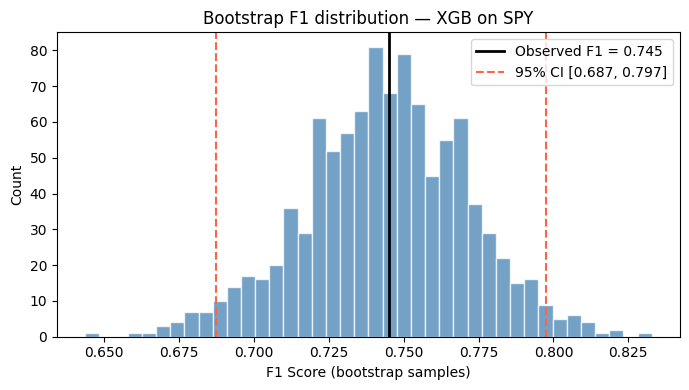

In [26]:
def plot_bootstrap_dist(y_true, y_pred, ticker, model_name, B=1000):
    f1_obs, ci_low, ci_high, f1_boot = bootstrap_f1_ci(y_true, y_pred, B=B)
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(f1_boot, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(f1_obs,  color='black',  lw=2,   label=f'Observed F1 = {f1_obs:.3f}')
    ax.axvline(ci_low,  color='tomato', lw=1.5, linestyle='--',
               label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
    ax.axvline(ci_high, color='tomato', lw=1.5, linestyle='--')
    ax.set_xlabel('F1 Score (bootstrap samples)')
    ax.set_ylabel('Count')
    ax.set_title(f'Bootstrap F1 distribution — {model_name} on {ticker}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'bootstrap_{model_name}_{ticker}.png', dpi=150)
    plt.show()


#xgb example
X_spy_test, y_spy_test = prepare_asset('SPY')
y_pred_xgb_spy = (xgb.predict_proba(X_spy_test) >= 0.85).astype(int)
plot_bootstrap_dist(y_spy_test, y_pred_xgb_spy, 'SPY', 'XGB')


In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

def walk_forward_validation(X, y, model_class, model_params, threshold,
                             n_splits=5, min_train_size=0.5):
    
    n = len(X)
    min_train = int(n * min_train_size)
    
    remaining = n - min_train
    fold_size = remaining // n_splits

    all_y_true = []
    all_y_pred = []
    rows = []

    for k in range(n_splits):
        train_end  = min_train + k * fold_size
        test_start = train_end
        test_end   = test_start + fold_size if k < n_splits - 1 else n

        X_tr = X.iloc[:train_end]
        y_tr = y.iloc[:train_end]
        X_te = X.iloc[test_start:test_end]
        y_te = y.iloc[test_start:test_end]

        # Skip if not enough positive
        if y_te.sum() < 2:
            print(f"Fold {k+1} skipped — too few positives ({y_te.sum()})")
            continue

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)

        proba  = model.predict_proba(X_te)
        y_pred = (proba >= threshold).astype(int)

        f1   = f1_score(y_te, y_pred, zero_division=0)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec  = recall_score(y_te, y_pred, zero_division=0)

        all_y_true.extend(y_te.tolist())
        all_y_pred.extend(y_pred.tolist())

        rows.append({
            'Fold':       k + 1,
            'Train_size': train_end,
            'Test_size':  len(y_te),
            'N_positive': int(y_te.sum()),
            'Precision':  round(prec, 3),
            'Recall':     round(rec,  3),
            'F1':         round(f1,   3),
        })
        print(f"Fold {k+1} | Train={train_end} | "
              f"N_pos={y_te.sum()} | F1={f1:.3f}")

    df_folds  = pd.DataFrame(rows)
    f1_global = f1_score(all_y_true, all_y_pred, zero_division=0)

    print("\n" + "="*55)
    print(df_folds.to_string(index=False))
    print(f"\nGlobal F1 (all folds concatenated) : {f1_global:.3f}")
    print(f"Mean F1 per fold                   : {df_folds['F1'].mean():.3f}")
    print(f"Std  F1 per fold                   : {df_folds['F1'].std():.3f}")

    return df_folds, f1_global


xgb_params = dict(
    n_estimators=138, max_depth=5, learning_rate=0.0430,
    subsample=0.7273, colsample_bytree=0.6976,
    gamma=0.0536, min_child_weight=1,
    eval_metric='logloss', verbosity=0
)

print("=== Walk-Forward — XGBoost ===")
df_wf_xgb, f1_xgb = walk_forward_validation(
    X, y, XGBModel, xgb_params, threshold=0.85
)

rfc_params = dict(
    n_estimators=346, max_depth=9,
    min_samples_split=17, min_samples_leaf=5,
    max_features=0.5463
)

print("\n=== Walk-Forward — RFC ===")
df_wf_rfc, f1_rfc = walk_forward_validation(
    X, y, RFCModel, rfc_params, threshold=0.65
)

=== Walk-Forward — XGBoost ===
Fold 1 skipped — too few positives (0)
Fold 2 | Train=3650 | N_pos=115 | F1=0.446
Fold 3 | Train=4258 | N_pos=68 | F1=0.673
Fold 4 | Train=4866 | N_pos=82 | F1=0.742
Fold 5 | Train=5474 | N_pos=30 | F1=0.617

 Fold  Train_size  Test_size  N_positive  Precision  Recall    F1
    2        3650        608         115      1.000   0.287 0.446
    3        4258        608          68      0.881   0.544 0.673
    4        4866        608          82      0.812   0.683 0.742
    5        5474        610          30      0.490   0.833 0.617

Global F1 (all folds concatenated) : 0.616
Mean F1 per fold                   : 0.619
Std  F1 per fold                   : 0.126

=== Walk-Forward — RFC ===
Fold 1 skipped — too few positives (0)
Fold 2 | Train=3650 | N_pos=115 | F1=0.598
Fold 3 | Train=4258 | N_pos=68 | F1=0.721
Fold 4 | Train=4866 | N_pos=82 | F1=0.739
Fold 5 | Train=5474 | N_pos=30 | F1=0.759

 Fold  Train_size  Test_size  N_positive  Precision  Recall    

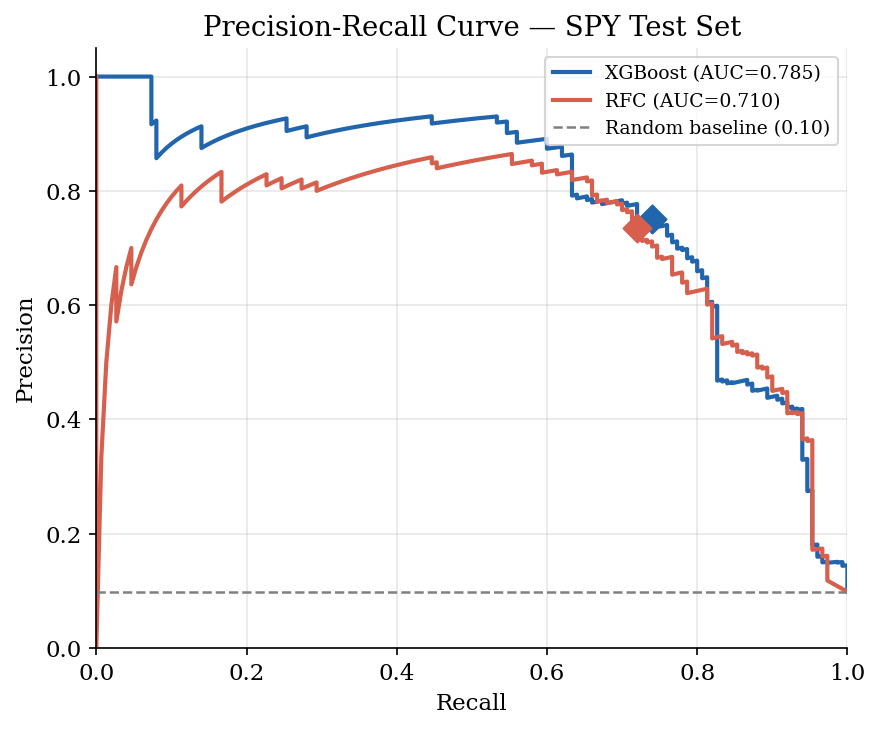

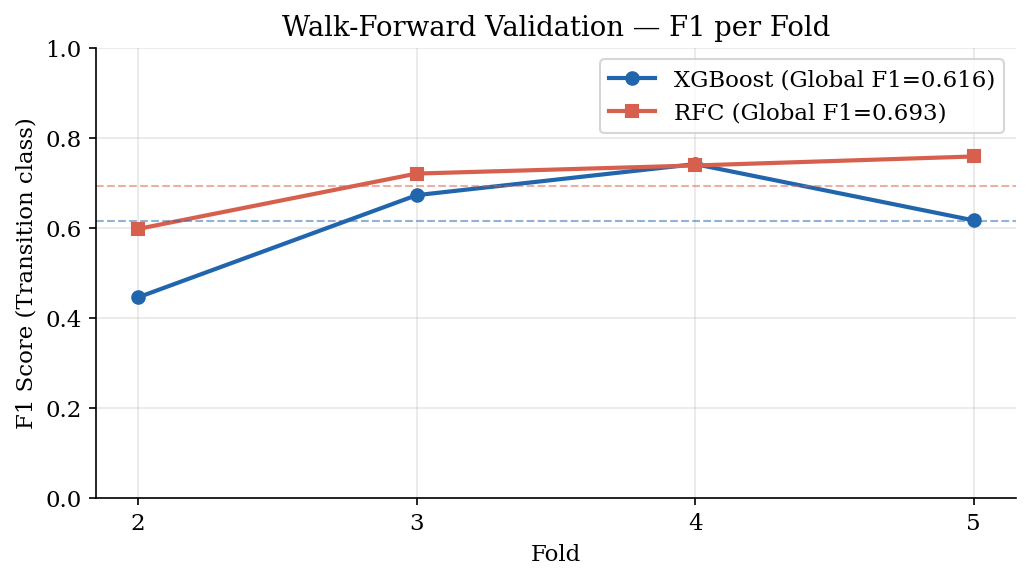

Saved: fig_walkforward.png


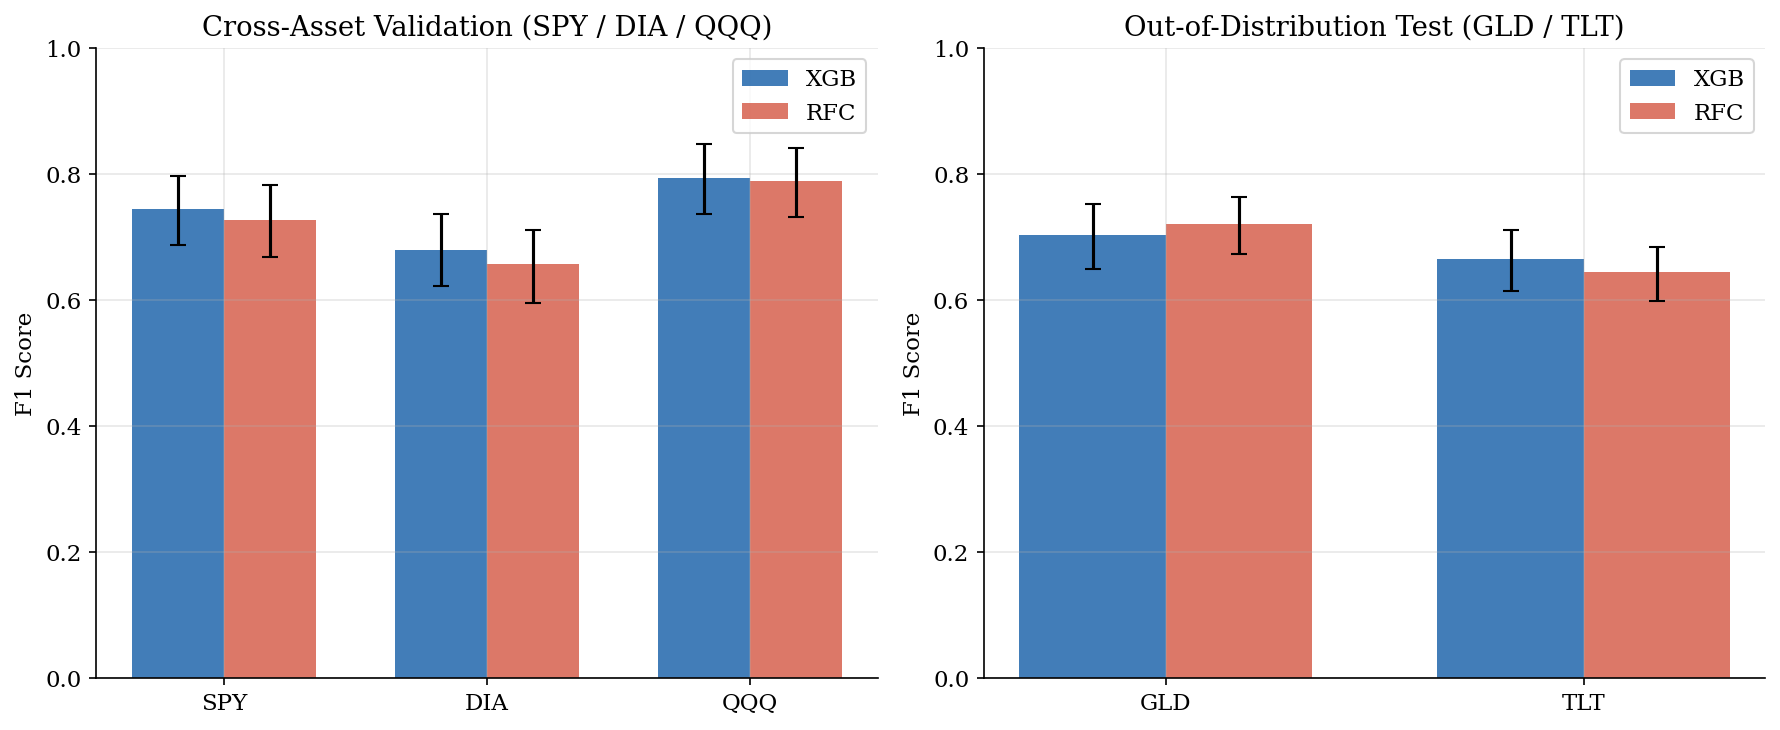

Saved: fig_cross_asset_ci.png


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score
)

# ── Style global ─────────────────────────────────────────────
plt.rcParams.update({
    'font.family':    'serif',
    'font.size':      11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':      True,
    'grid.alpha':     0.3,
    'figure.dpi':     150,
})

COLORS = {'XGB': '#2166ac', 'RFC': '#d6604d'}


# ════════════════════════════════════════════════════════════
# FIG 1 — Precision-Recall curves (SPY, both models)
# ════════════════════════════════════════════════════════════
def plot_precision_recall(y_test, y_proba_xgb, y_proba_rfc,
                           thresh_xgb=0.85, thresh_rfc=0.65):
    fig, ax = plt.subplots(figsize=(6, 5))

    for proba, name, color, thresh in [
        (y_proba_xgb, 'XGBoost', COLORS['XGB'], thresh_xgb),
        (y_proba_rfc, 'RFC',     COLORS['RFC'], thresh_rfc),
    ]:
        prec, rec, _ = precision_recall_curve(y_test, proba)
        pr_auc = auc(rec, prec)
        ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AUC={pr_auc:.3f})')

        # Operating point — annotation textuelle plutôt que legend
        y_pred = (proba >= thresh).astype(int)
        p_op = precision_score(y_test, y_pred, zero_division=0)
        r_op = recall_score(y_test, y_pred, zero_division=0)
        ax.scatter(r_op, p_op, color=color, s=90, zorder=5, marker='D')

    baseline = y_test.mean()
    ax.axhline(baseline, color='gray', lw=1.2, linestyle='--',
               label=f'Random baseline ({baseline:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve — SPY Test Set')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig('fig_precision_recall.png', dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════
# FIG 3 — Walk-Forward F1 per fold
# ════════════════════════════════════════════════════════════
def plot_walkforward(df_wf_xgb, df_wf_rfc, f1_xgb_global, f1_rfc_global):
    fig, ax = plt.subplots(figsize=(7, 4))

    folds = df_wf_xgb['Fold'].values

    ax.plot(folds, df_wf_xgb['F1'], marker='o', color=COLORS['XGB'],
            lw=2, label=f'XGBoost (Global F1={f1_xgb_global:.3f})')
    ax.plot(folds, df_wf_rfc['F1'], marker='s', color=COLORS['RFC'],
            lw=2, label=f'RFC (Global F1={f1_rfc_global:.3f})')

    # Global F1 horizontal lines
    ax.axhline(f1_xgb_global, color=COLORS['XGB'], lw=1,
               linestyle='--', alpha=0.5)
    ax.axhline(f1_rfc_global, color=COLORS['RFC'],  lw=1,
               linestyle='--', alpha=0.5)

    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Score (Transition class)')
    ax.set_title('Walk-Forward Validation — F1 per Fold')
    ax.set_xticks(folds)
    ax.set_ylim([0, 1])
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_walkforward.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig_walkforward.png")


# ════════════════════════════════════════════════════════════
# FIG 4 — Cross-asset F1 with Bootstrap CI
# ════════════════════════════════════════════════════════════
def plot_cross_asset_ci(df_ci, assets_main, assets_ood=None):
    """
    df_ci : DataFrame avec colonnes Asset, Model, F1, CI_low, CI_high
    assets_main : liste des assets principaux (SPY, DIA, QQQ)
    assets_ood  : liste des assets OOD (GLD, TLT) — affichés séparément
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    for ax, assets, title in [
        (axes[0], assets_main, 'Cross-Asset Validation (SPY / DIA / QQQ)'),
        (axes[1], assets_ood,  'Out-of-Distribution Test (GLD / TLT)'),
    ]:
        df_plot = df_ci[df_ci['Asset'].isin(assets)].copy()
        x = np.arange(len(assets))
        width = 0.35

        for i, (model, color) in enumerate([('XGB', COLORS['XGB']),
                                             ('RFC', COLORS['RFC'])]):
            df_m = df_plot[df_plot['Model'] == model].set_index('Asset')
            f1s    = [df_m.loc[a, 'F1']     for a in assets]
            ci_low = [df_m.loc[a, 'CI_low'] for a in assets]
            ci_hi  = [df_m.loc[a, 'CI_high']for a in assets]
            yerr   = [
                [f - l for f, l in zip(f1s, ci_low)],
                [h - f for f, h in zip(f1s, ci_hi)]
            ]
            ax.bar(x + i*width, f1s, width, color=color, alpha=0.85,
                   label=model, yerr=yerr, capsize=4, error_kw={'lw': 1.5})

        ax.set_xticks(x + width/2)
        ax.set_xticklabels(assets)
        ax.set_ylabel('F1 Score')
        ax.set_ylim([0, 1])
        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    plt.savefig('fig_cross_asset_ci.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig_cross_asset_ci.png")


# ════════════════════════════════════════════════════════════
# APPELS — remplace les variables par les tiennes
# ════════════════════════════════════════════════════════════

# Fig 1 — Precision-Recall
plot_precision_recall(y_test, y_proba_xgb, y_proba_rfc,
                      thresh_xgb=0.85, thresh_rfc=0.65)

# Fig 2 — Feature Importance
feature_names = COLUMN_ORDER   # depuis src.features

# Fig 3 — Walk-Forward
plot_walkforward(df_wf_xgb, df_wf_rfc,
                 f1_xgb_global=0.616, f1_rfc_global=0.693)

# Fig 4 — Cross-asset CI
# df_ci doit contenir GLD et TLT aussi
plot_cross_asset_ci(
    df_ci,
    assets_main=['SPY', 'DIA', 'QQQ'],
    assets_ood=['GLD', 'TLT']
)